# Writing a Custom Feature Engineering Method

This notebook walks through creating a custom FE method that integrates with Feature Forge's plugin architecture. You'll learn:

1. The `MethodProtocol` contract (duck-typing, zero imports needed)
2. Using `BaseMethod` for full artifact support
3. Registration via entry points and programmatic API
4. Running comparisons with built-in methods

In [1]:
import os
import pathlib
import sys
import warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('FF_LOG_LEVEL', 'warning')
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import pandas as pd
import numpy as np
from _utils import get_llm_client, load_heart_disease

X_train, X_test, y_train, y_test = load_heart_disease()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (212, 13), Test: (91, 13)


## 1. Understanding `MethodProtocol`

`MethodProtocol` is a `@runtime_checkable` Protocol — any class with the right methods satisfies it, no imports needed.

Required interface:
- `name: str`
- `fit(X_train, y_train) -> Self`
- `transform(X) -> pd.DataFrame`
- `fit_transform(X_train, y_train) -> pd.DataFrame`
- `generated_scripts -> list[str]`
- `feature_metadata -> list[dict]`
- `get_artifacts() -> dict`

In [2]:
from feature_forge.methods.base import MethodProtocol

# MethodProtocol is runtime-checkable
class DuckTypedMethod:
    name = "duck_typed"
    def fit(self, X_train, y_train): return self
    def transform(self, X): return pd.DataFrame()
    def fit_transform(self, X_train, y_train): return pd.DataFrame()
    @property
    def generated_scripts(self): return []
    @property
    def feature_metadata(self): return []
    def get_artifacts(self): return {}

obj = DuckTypedMethod()
print(f'Satisfies MethodProtocol: {isinstance(obj, MethodProtocol)}')

Satisfies MethodProtocol: True


## 2. Option A: Protocol-Compliant (Zero Imports)

Best for: third-party packages that don't want a feature_forge dependency.

In [3]:
class StatisticalFeatures:
    """Generate statistical features without any feature_forge imports."""
    name = "statistical_features"

    def __init__(self, quantiles=(0.25, 0.5, 0.75)):
        self._quantiles = quantiles
        self._code = ""

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> "StatisticalFeatures":
        self._numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
        self._code = f"# Statistical features for {len(self._numeric_cols)} numeric columns"
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        result = pd.DataFrame(index=X.index)
        for col in self._numeric_cols:
            for q in self._quantiles:
                qval = X[col].quantile(q)
                result[f"{col}_above_q{int(q*100)}"] = (X[col] > qval).astype(int)
            result[f"{col}_zscore"] = (X[col] - X[col].mean()) / (X[col].std() + 1e-8)
            result[f"{col}_rank"] = X[col].rank(pct=True)
        return result

    def fit_transform(self, X_train: pd.DataFrame, y_train: pd.Series) -> pd.DataFrame:
        self.fit(X_train, y_train)
        return self.transform(X_train)

    @property
    def generated_scripts(self) -> list[str]:
        return [self._code] if self._code else []

    @property
    def feature_metadata(self) -> list[dict]:
        return [{"name": "statistical_features", "type": "numerical", "method": "statistical"}]

    def get_artifacts(self) -> dict:
        return {"numeric_columns": self._numeric_cols}

# Test it
sf = StatisticalFeatures()
X_enhanced = sf.fit_transform(X_train, y_train)
print(f'Generated {X_enhanced.shape[1]} features from {len(sf._numeric_cols)} columns')
print(f'Satisfies MethodProtocol: {isinstance(sf, MethodProtocol)}')
X_enhanced.head(3)

Generated 65 features from 13 columns
Satisfies MethodProtocol: True


,age_above_q25,age_above_q50,age_above_q75,age_zscore,age_rank,sex_above_q25,sex_above_q50,sex_above_q75,sex_zscore,sex_rank,...,colored_vessels_above_q25,colored_vessels_above_q50,colored_vessels_above_q75,colored_vessels_zscore,colored_vessels_rank,thalassemia_above_q25,thalassemia_above_q50,thalassemia_above_q75,thalassemia_zscore,thalassemia_rank
189,1,0,0,-0.490823,0.313679,0,0,0,-0.663394,0.349057,...,0,0,0,-0.690756,0.306604,0,0,0,-0.861619,0.280660
202,1,1,1,1.063886,0.841981,1,1,0,1.500290,0.849057,...,0,0,0,-0.690756,0.306604,1,1,0,1.214100,0.808962
286,1,1,0,0.397582,0.625000,0,0,0,-0.663394,0.349057,...,0,0,0,-0.690756,0.306604,1,1,0,1.214100,0.808962


## 3. Option B: `BaseMethod` Subclass (Full Artifact Support)

Best for: methods that want artifact storage, settings integration, and provenance tracking.

In [4]:
from feature_forge.methods.base import BaseMethod
from feature_forge.artifacts.base import ArtifactConfig

class InteractionFeatures(BaseMethod):
    """Generate pairwise interaction features with artifact tracking."""

    def __init__(self, max_pairs: int = 10, artifact_config: ArtifactConfig | None = None):
        super().__init__("interaction_features", artifact_config=artifact_config)
        self._max_pairs = max_pairs
        self._code = ""
        self._pairs: list[tuple[str, str]] = []

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series) -> "InteractionFeatures":
        numeric = X_train.select_dtypes(include=[np.number]).columns.tolist()
        self._pairs = []
        for i, c1 in enumerate(numeric):
            for c2 in numeric[i+1:]:
                if len(self._pairs) >= self._max_pairs:
                    break
                self._pairs.append((c1, c2))
            if len(self._pairs) >= self._max_pairs:
                break

        self._code = "# Interaction features\n"
        for c1, c2 in self._pairs:
            self._code += f"# {c1}_x_{c2} = df['{c1}'] * df['{c2}']\n"

        self._artifacts["pairs"] = self._pairs
        self._artifacts["generated_code"] = self._code
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        result = pd.DataFrame(index=X.index)
        for c1, c2 in self._pairs:
            result[f"{c1}_x_{c2}"] = X[c1].values * X[c2].values
        return result

# Test it
interact = InteractionFeatures(max_pairs=8)
X_interact = interact.fit_transform(X_train, y_train)
print(f'Generated {X_interact.shape[1]} interaction features')
print(f'Artifacts: {list(interact.get_artifacts().keys())}')
print(f'Code preview: {interact.generated_scripts[0][:100]}...')
X_interact.head(3)

Generated 8 interaction features
Artifacts: ['pairs', 'generated_code']
Code preview: # Interaction features
# age_x_sex = df['age'] * df['sex']
# age_x_chest_pain_type = df['age'] * df[...


,age_x_sex,age_x_chest_pain_type,age_x_resting_bp,age_x_cholesterol,age_x_fasting_blood_sugar,age_x_rest_ecg,age_x_max_heart_rate,age_x_exercise_angina
189,0,100,6450,9800,0,0,8150,0
202,64,128,8960,20032,0,0,8512,0
286,0,174,7250,12760,0,0,8352,0


## 4. Registration

### Via Entry Points (for packages)

In your `pyproject.toml`:

```toml
[project.entry-points."feature_forge.methods"]
statistical = "my_package:StatisticalFeatures"
interaction = "my_package:InteractionFeatures"
```

After `pip install`, methods are auto-discovered by `MethodRegistry`.

### Programmatic (for notebooks/scripts)

In [5]:
from feature_forge import ExperimentalPlatform
from feature_forge.methods import MethodRegistry

# Programmatic registration
platform = ExperimentalPlatform()
platform.register_method("statistical", StatisticalFeatures)
platform.register_method("interaction", InteractionFeatures)

print('Registered methods:')
for name in sorted(platform.list_methods()):
    print(f'  {name}')

# Verify protocol compliance
from feature_forge.methods.base import MethodProtocol
for cls in [StatisticalFeatures, InteractionFeatures]:
    instance = cls()
    assert isinstance(instance, MethodProtocol), f"{cls.__name__} doesn't satisfy MethodProtocol"
    print(f'{cls.__name__}: Protocol OK')

Registered methods:
  caafe
  interaction
  llmfe
  malmas
  malmus
  openfe
  statistical
StatisticalFeatures: Protocol OK
InteractionFeatures: Protocol OK


## 5. Running Comparisons

Use `ExperimentalPlatform.run()` to compare your method against built-in ones.

In [6]:
from feature_forge.evaluation import CVEvaluator

evaluator = CVEvaluator()
baseline_auc = evaluator.evaluate_baseline(X_train, y_train)
print(f'Baseline AUC (no FE): {baseline_auc:.4f}')

results = []
for MethodCls in [StatisticalFeatures, InteractionFeatures]:
    method = MethodCls()
    method.fit(X_train, y_train)
    X_enhanced = method.transform(X_train)
    X_full = pd.concat([X_train, X_enhanced], axis=1)
    gain = evaluator.evaluate_feature(X_train, y_train, X_enhanced, baseline_score=baseline_auc)
    results.append({
        'method': method.name,
        'n_features': X_enhanced.shape[1],
        'cv_gain': gain,
    })

results_df = pd.DataFrame(results)
print('\nComparison Results:')
print(results_df.to_string(index=False))

Baseline AUC (no FE): 0.8707



Comparison Results:
              method  n_features  cv_gain
statistical_features          65 0.000000
interaction_features          10 0.002632


## 6. Inspecting Artifacts

Each method collects artifacts during fit/transform for provenance and reproducibility.

In [7]:
# Inspect artifacts from the interaction method
artifacts = interact.get_artifacts()
print('Artifact keys:', list(artifacts.keys()))
print(f'Number of pairs: {len(artifacts["pairs"])}')
print(f'First 3 pairs: {artifacts["pairs"][:3]}')
print(f'\nGenerated code:\n{artifacts["generated_code"][:200]}...')

# Feature metadata
print(f'\nFeature metadata: {interact.feature_metadata}')
print(f'Generated scripts: {len(interact.generated_scripts)} script(s)')

Artifact keys: ['pairs', 'generated_code']
Number of pairs: 8
First 3 pairs: [('age', 'sex'), ('age', 'chest_pain_type'), ('age', 'resting_bp')]

Generated code:
# Interaction features
# age_x_sex = df['age'] * df['sex']
# age_x_chest_pain_type = df['age'] * df['chest_pain_type']
# age_x_resting_bp = df['age'] * df['resting_bp']
# age_x_cholesterol = df['age']...

Feature metadata: []
Generated scripts: 1 script(s)


## 7. Evaluating Against Built-in Methods

Compare your custom method against built-in methods on the same dataset.

⚠️  No LLM API key found. Set DEEPSEEK_API_KEY or OPENAI_API_KEY to run LLM-dependent cells.
The number of candidate features is 1712
Start stage I selection.


  0%|          | 0/4 [00:00<?, ?it/s]

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 7, number of negative: 14
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 21, number of used features: 0
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing 


[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 7, number of negative: 14
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 21, number of used features: 0
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] There are no meaningful features which satisfy the provi

 25%|██▌       | 1/4 [00:01<00:04,  1.59s/it]

...

[LightGBM] [Info] Number of positive: 77, number of negative: 92
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000005 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3
[LightGBM] [Info] Number of data points in the train set: 169, number of used features: 1
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
The number of remaining candidate features is 1
Start stage II selection.


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.00s/it]

100%|██████████| 1/1 [00:01<00:00,  1.00s/it]

Finish data processing.
[LightGBM] [Info] Number of positive: 77, number of negative: 92
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000030 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 198
[LightGBM] [Info] Number of data points in the train set: 169, number of used features: 14
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

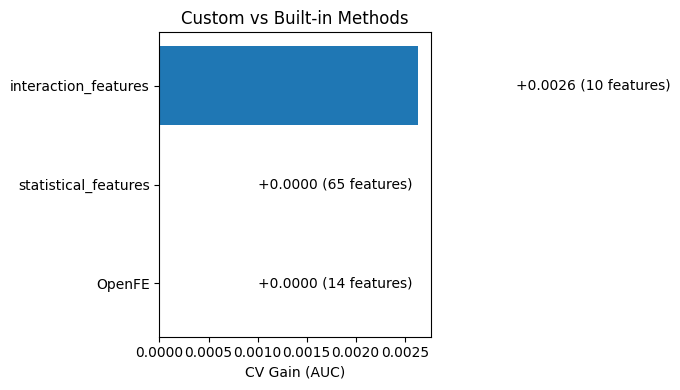

In [8]:
from feature_forge.methods import MethodRegistry

llm = get_llm_client()

all_results = []

# Built-in non-LLM method
try:
    from feature_forge.methods.openfe.method import OpenFEMethod
    ofe = OpenFEMethod()
    ofe.fit(X_train, y_train)
    X_ofe = ofe.transform(X_train)
    gain = evaluator.evaluate_feature(X_train, y_train, X_ofe, baseline_score=baseline_auc)
    all_results.append({'method': 'OpenFE', 'n_features': X_ofe.shape[1], 'gain': gain})
except Exception as e:
    print(f'OpenFE skipped: {e}')

# Our custom methods
for MethodCls in [StatisticalFeatures, InteractionFeatures]:
    method = MethodCls()
    method.fit(X_train, y_train)
    X_enhanced = method.transform(X_train)
    gain = evaluator.evaluate_feature(X_train, y_train, X_enhanced, baseline_score=baseline_auc)
    all_results.append({'method': method.name, 'n_features': X_enhanced.shape[1], 'gain': gain})

if all_results:
    import matplotlib.pyplot as plt
    df = pd.DataFrame(all_results)
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(df['method'], df['gain'])
    ax.set_xlabel('CV Gain (AUC)')
    ax.set_title('Custom vs Built-in Methods')
    for bar, nf in zip(bars, df['n_features']):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'+{bar.get_width():.4f} ({nf} features)', va='center')
    plt.tight_layout()
    plt.show()
else:
    print('No results to plot')

## Summary

| Approach | When to Use | feature_forge Dependency |
|----------|-------------|--------------------------|
| **Protocol-compliant** | Third-party packages, zero coupling | None |
| **BaseMethod subclass** | Full artifact support, settings integration | Yes |

**Key takeaways:**
- Any class with `fit/transform/fit_transform/generated_scripts/feature_metadata/get_artifacts` works
- Register via `pyproject.toml` entry points for distribution, or `platform.register_method()` for notebooks
- `ExperimentalPlatform.run(methods=[...])` makes custom methods first-class citizens in experiments
- `get_artifacts()` provides provenance tracking for reproducibility